In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [5]:
df['who'].value_counts()


who
man      537
woman    271
child     83
Name: count, dtype: int64

In [6]:
df= df[['survived','pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked','who']]
df.dropna(inplace= True)
# df.drop(['class', 'adult_male', 'deck', 'embark_town', 'alive', 'alone'])

/tmp/ipykernel_39017/2179801232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace= True)


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,0.404494,2.240169,29.642093,0.514045,0.432584,34.567251
std,0.491139,0.836854,14.492933,0.930692,0.854181,52.938648
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,20.000000,0.000000,0.000000,8.050000
50%,0.000000,2.000000,28.000000,0.000000,0.000000,15.645850
75%,1.000000,3.000000,38.000000,1.000000,1.000000,33.000000
max,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  712 non-null    int64  
 1   pclass    712 non-null    int64  
 2   sex       712 non-null    object 
 3   age       712 non-null    float64
 4   sibsp     712 non-null    int64  
 5   parch     712 non-null    int64  
 6   fare      712 non-null    float64
 7   embarked  712 non-null    object 
 8   who       712 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 55.6+ KB


<Axes: xlabel='age', ylabel='survived'>

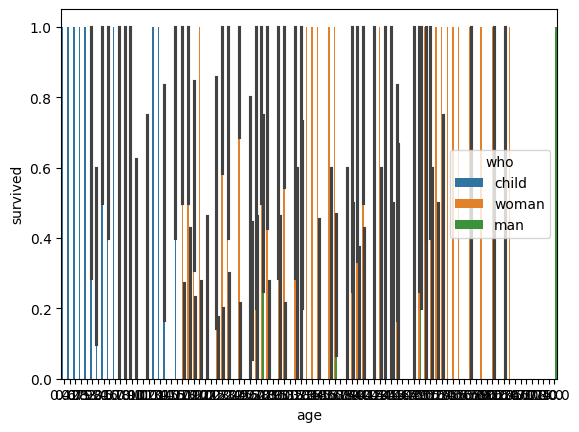

In [9]:
sns.barplot(data=df,x='age', y='survived', hue='who')

<Axes: xlabel='embarked', ylabel='survived'>

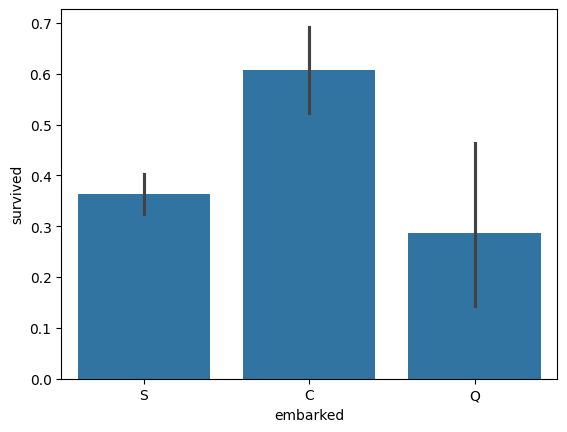

In [10]:
sns.barplot(data=df,x='embarked', y='survived')

<Axes: xlabel='sibsp', ylabel='survived'>

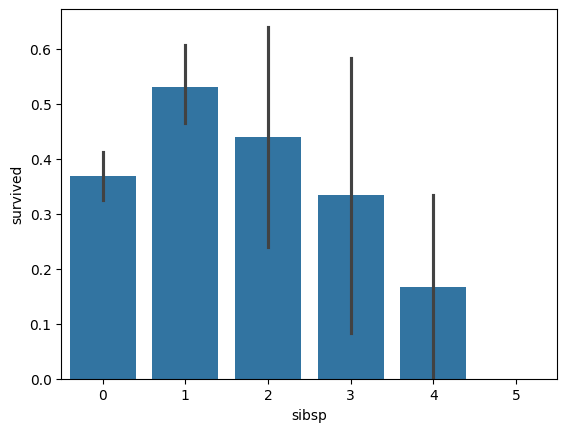

In [11]:
sns.barplot(data=df,x='sibsp', y='survived')

<Axes: ylabel='fare'>

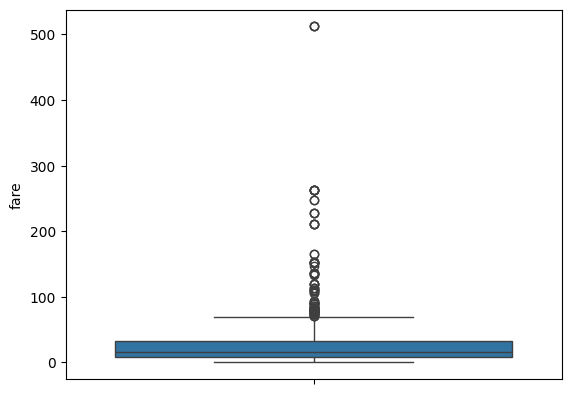

In [12]:
# sns.scatterplot(data=df, x='age', y='fare')
sns.boxplot(data=df, y='fare')

In [13]:
q1= df['fare'].quantile(0.25)
q3= df['fare'].quantile(0.75)
IQR= q3-q1
l_bound= q1-1.5*IQR
u_bound= q3+1.5*IQR
print(l_bound, u_bound)
df= df[(df['fare']>= l_bound) & (df['fare'] <= u_bound)]

-29.374999999999996 70.425


<Axes: ylabel='fare'>

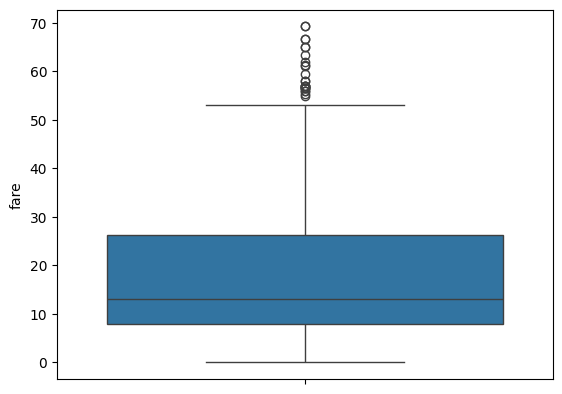

In [14]:
sns.boxplot(data=df, y='fare')

In [15]:
df.shape

(617, 9)

In [16]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000
mean,0.356564,2.423015,28.919368,0.487844,0.398703,19.026803
std,0.479373,0.741393,14.326895,0.953598,0.846995,14.282146
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,13.000000
75%,1.000000,3.000000,36.500000,1.000000,0.000000,26.283300
max,1.000000,3.000000,80.000000,5.000000,6.000000,69.300000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  617 non-null    int64  
 1   pclass    617 non-null    int64  
 2   sex       617 non-null    object 
 3   age       617 non-null    float64
 4   sibsp     617 non-null    int64  
 5   parch     617 non-null    int64  
 6   fare      617 non-null    float64
 7   embarked  617 non-null    object 
 8   who       617 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 48.2+ KB


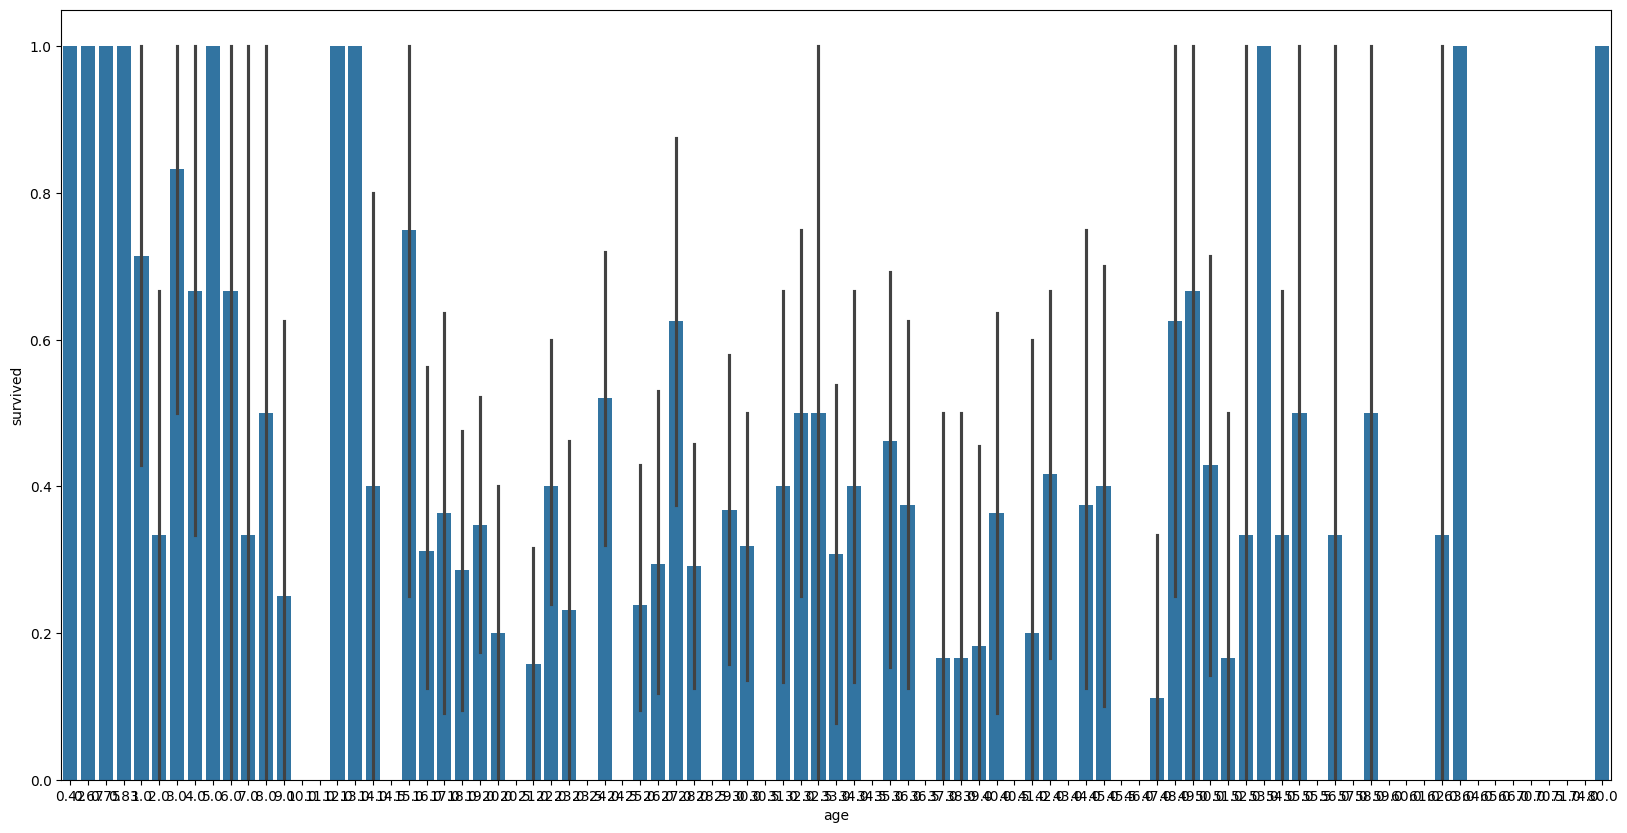

In [18]:
plt.figure(figsize=(20,10))
# sns.heatmap(df.corr(), annot=True)
sns.barplot(data=df, x='age', y='survived')
plt.show()

<Axes: xlabel='pclass', ylabel='survived'>

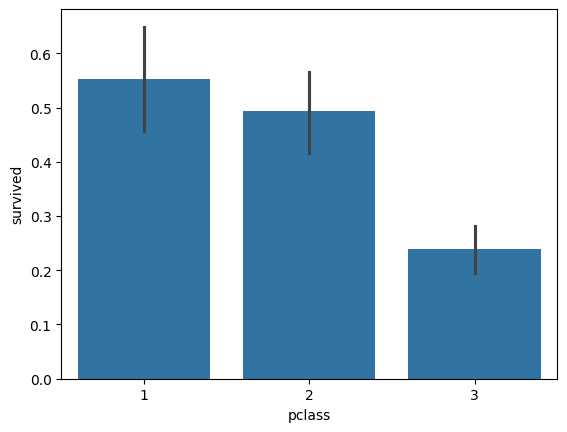

In [19]:
sns.barplot(data=df, x='pclass', y='survived')

<Axes: xlabel='embarked', ylabel='pclass'>

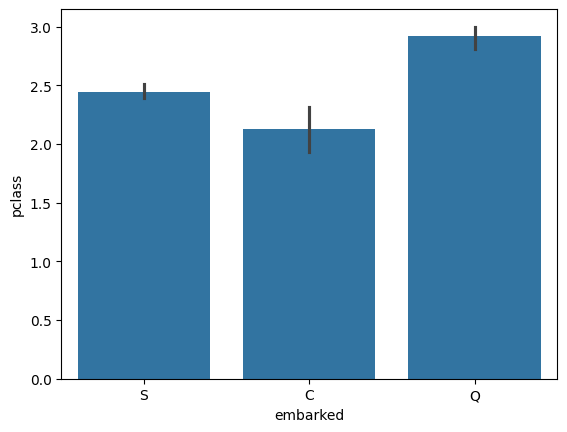

In [20]:
sns.barplot(data=df, x='embarked', y='pclass')

In [21]:
df= pd.get_dummies(df, columns=['embarked'], drop_first=True)

In [22]:
df= pd.get_dummies(df, columns=['who'])

In [23]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,male,22.0,1,0,7.2500,False,True,False,True,False
2,1,3,female,26.0,0,0,7.9250,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,False,True,False,False,True
4,0,3,male,35.0,0,0,8.0500,False,True,False,True,False
6,0,1,male,54.0,0,0,51.8625,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,True,False,False,False,True
886,0,2,male,27.0,0,0,13.0000,False,True,False,True,False
887,1,1,female,19.0,0,0,30.0000,False,True,False,False,True
889,1,1,male,26.0,0,0,30.0000,False,False,False,True,False


In [24]:
df.drop(['parch', 'sibsp'], axis=1, inplace=True)

In [25]:
df['sex']= df['sex'].map({'male':0, 'female':1})
df['who_child']= df['who_child'].astype(int)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    617 non-null    int64  
 1   pclass      617 non-null    int64  
 2   sex         617 non-null    int64  
 3   age         617 non-null    float64
 4   fare        617 non-null    float64
 5   embarked_Q  617 non-null    bool   
 6   embarked_S  617 non-null    bool   
 7   who_child   617 non-null    int64  
 8   who_man     617 non-null    bool   
 9   who_woman   617 non-null    bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 36.2 KB


In [27]:
df[('embarked_Q')]= df[('embarked_Q')].astype(int)
df[('embarked_S')]= df[('embarked_S')].astype(int)


In [28]:
df

,survived,pclass,sex,age,fare,embarked_Q,embarked_S,who_child,who_man,who_woman
0,0,3,0,22.0,7.2500,0,1,0,True,False
2,1,3,1,26.0,7.9250,0,1,0,False,True
3,1,1,1,35.0,53.1000,0,1,0,False,True
4,0,3,0,35.0,8.0500,0,1,0,True,False
6,0,1,0,54.0,51.8625,0,1,0,True,False
...,...,...,...,...,...,...,...,...,...,...
885,0,3,1,39.0,29.1250,1,0,0,False,True
886,0,2,0,27.0,13.0000,0,1,0,True,False
887,1,1,1,19.0,30.0000,0,1,0,False,True
889,1,1,0,26.0,30.0000,0,0,0,True,False


In [30]:
df.drop(['who_man', 'who_woman'], axis=1, inplace=True)

In [31]:
df.to_csv('titanic_cleaned.csv', index=False)

In [369]:
# X = df.drop(['survived', 'embarked_C', 'embarked_Q', 'embarked_S', 'who_child'], axis=1)
# Y = df['survived']

In [ ]:
X = df.drop(['survived'], axis=1)
Y = df['survived']

In [371]:
X.shape, Y.shape

((617, 7), (617,))

<Axes: >

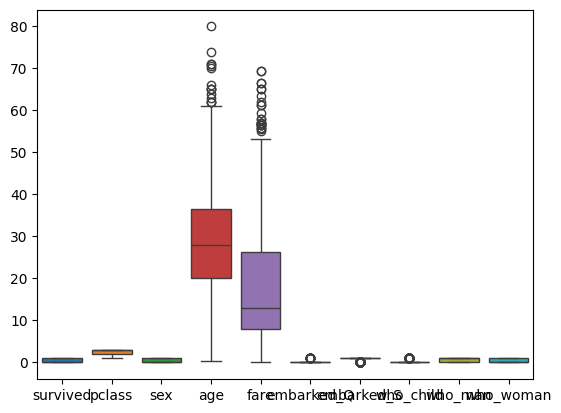

In [372]:
sns.boxplot(df)

In [373]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(X,Y, test_size=0.2, random_state=42)

In [374]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [375]:
# sns.boxplot(x_train)

In [376]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((493, 7), (124, 7), (493,), (124,))

Logistic Regression

In [377]:
from sklearn.linear_model import LogisticRegression
model= LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [378]:
model.score(x_train, y_train)*100, model.score(x_test, y_test)*100

(81.7444219066937, 76.61290322580645)

In [379]:
y_pred_lgr= model.predict(x_test)

In [380]:
y_pred_lgr.shape

(124,)

In [381]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred_lgr))
print("Accuracy Score\n",accuracy_score(y_test, y_pred_lgr))
print("Classification Report\n",classification_report(y_test, y_pred_lgr))
acc_lgr= accuracy_score(y_test, y_pred_lgr)*100

Confusion Matrix
 [[73 12]
 [17 22]]
Accuracy Score
 0.7661290322580645
Classification Report
               precision    recall  f1-score   support

           0       0.81      0.86      0.83        85
           1       0.65      0.56      0.60        39

    accuracy                           0.77       124
   macro avg       0.73      0.71      0.72       124
weighted avg       0.76      0.77      0.76       124



In [382]:
x_test, y_test

(array([[ 7.77626525e-01, -7.22222222e-01, -2.06153045e-01,
         -3.37605458e-01, -2.10930143e-01, -2.13056937e+00,
         -3.86243640e-01],
        [ 7.77626525e-01, -7.22222222e-01,  4.04971766e-01,
         -8.01657715e-01, -2.10930143e-01, -2.13056937e+00,
         -3.86243640e-01],
        [ 7.77626525e-01, -7.22222222e-01,  2.81551963e+00,
         -8.11974075e-01,  4.74090608e+00, -2.13056937e+00,
         -3.86243640e-01],
        [-5.96459055e-01,  1.38461538e+00,  1.08399933e+00,
          4.97029148e-01, -2.10930143e-01,  4.69358104e-01,
         -3.86243640e-01],
        [-1.97054464e+00,  1.38461538e+00, -4.77764072e-01,
          3.35207131e+00, -2.10930143e-01,  4.69358104e-01,
         -3.86243640e-01],
        [ 7.77626525e-01, -7.22222222e-01, -6.13569586e-01,
         -6.63681699e-01, -2.10930143e-01,  4.69358104e-01,
         -3.86243640e-01],
        [ 7.77626525e-01, -7.22222222e-01, -5.45666829e-01,
         -8.08733408e-01, -2.10930143e-01,  4.69358104e-01

In [383]:
# # model.predict([[3,1,26.0,7.9250,0,0,1,0]])
# model.predict([[2,    1,  45.0,  26.2500,           0,           0,           1,          0]])

Naive Bayes Classifier

In [384]:
from sklearn.naive_bayes import GaussianNB
gnb= GaussianNB()
gnb.fit(x_train, y_train)

GaussianNB()

In [385]:
gnb.score(x_train, y_train)*100, gnb.score(x_test, y_test)*100

(77.28194726166329, 73.38709677419355)

In [386]:
y_pred_gnb= gnb.predict(x_test)

In [387]:
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred_gnb))
print("Accuracy Score\n",accuracy_score(y_test, y_pred_gnb))
print("Classification Report\n",classification_report(y_test, y_pred_gnb))
acc_gnb= accuracy_score(y_test, y_pred_gnb)*100

Confusion Matrix
 [[68 17]
 [16 23]]
Accuracy Score
 0.7338709677419355
Classification Report
               precision    recall  f1-score   support

           0       0.81      0.80      0.80        85
           1       0.57      0.59      0.58        39

    accuracy                           0.73       124
   macro avg       0.69      0.69      0.69       124
weighted avg       0.74      0.73      0.73       124



Random Forest Classifier

In [388]:
# Random Forests
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier()
random_forest.fit(x_train, y_train)
y_pred_rfc = random_forest.predict(x_test)
train_score= random_forest.score(x_train,y_train)
acc_rfc = round(random_forest.score(x_test, y_test) * 100, 2)

print("Important features")
# pd.Series(random_forest.feature_importances_,x_train.columns).sort_values(ascending=True).plot.barh(width=0.8)
print('__'*30)
print('Train Score: ', train_score)
print('__'*30)
print('Test Score: ', acc_rfc)


Important features
____________________________________________________________
Train Score:  0.9837728194726166
____________________________________________________________
Test Score:  81.45


In [389]:
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred_rfc))
print("Accuracy Score\n",accuracy_score(y_test, y_pred_rfc))
print("Classification Report\n",classification_report(y_test, y_pred_rfc))


Confusion Matrix
 [[75 10]
 [13 26]]
Accuracy Score
 0.8145161290322581
Classification Report
               precision    recall  f1-score   support

           0       0.85      0.88      0.87        85
           1       0.72      0.67      0.69        39

    accuracy                           0.81       124
   macro avg       0.79      0.77      0.78       124
weighted avg       0.81      0.81      0.81       124



Support Vector Machine

In [418]:
from sklearn.svm import SVC
svc= SVC(C= 10, kernel= 'rbf')
svc.fit(x_train, y_train)
print(svc.score(x_train, y_train)*100, svc.score(x_test, y_test)*100)
y_pred_svc= svc.predict(x_test)

85.80121703853956 82.25806451612904


In [419]:
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred_svc))
print("Accuracy Score\n",accuracy_score(y_test, y_pred_svc))
print("Classification Report\n",classification_report(y_test, y_pred_svc))
acc_svc= accuracy_score(y_test, y_pred_svc)*100

Confusion Matrix
 [[79  6]
 [16 23]]
Accuracy Score
 0.8225806451612904
Classification Report
               precision    recall  f1-score   support

           0       0.83      0.93      0.88        85
           1       0.79      0.59      0.68        39

    accuracy                           0.82       124
   macro avg       0.81      0.76      0.78       124
weighted avg       0.82      0.82      0.81       124



KNN

In [397]:
from sklearn.neighbors import KNeighborsClassifier
knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
print(knn.score(x_train, y_train)*100, knn.score(x_test, y_test))
y_pred_knn= knn.predict(x_test)

print("Confusion Matrix\n",confusion_matrix(y_test, y_pred_knn))
print("Accuracy Score\n",accuracy_score(y_test, y_pred_knn))
print("Classification Report\n",classification_report(y_test, y_pred_knn))
acc_knn= accuracy_score(y_test, y_pred_knn)*100

85.80121703853956 0.8306451612903226
Confusion Matrix
 [[75 10]
 [11 28]]
Accuracy Score
 0.8306451612903226
Classification Report
               precision    recall  f1-score   support

           0       0.87      0.88      0.88        85
           1       0.74      0.72      0.73        39

    accuracy                           0.83       124
   macro avg       0.80      0.80      0.80       124
weighted avg       0.83      0.83      0.83       124



AdaBoost Classifier

In [393]:
from sklearn.ensemble import AdaBoostClassifier
abc= AdaBoostClassifier()
abc.fit(x_train, y_train)
print(abc.score(x_train, y_train)*100, abc.score(x_test, y_test)*100)
y_pred_abc= abc.predict(x_test)

print("Confusion Matrix\n",confusion_matrix(y_test, y_pred_knn))
print("Accuracy Score\n",accuracy_score(y_test, y_pred_knn))
print("Classification Report\n",classification_report(y_test, y_pred_knn))
acc_abc= accuracy_score(y_test, y_pred_knn)*100

80.52738336713996 79.83870967741935
Confusion Matrix
 [[79  6]
 [17 22]]
Accuracy Score
 0.8145161290322581
Classification Report
               precision    recall  f1-score   support

           0       0.82      0.93      0.87        85
           1       0.79      0.56      0.66        39

    accuracy                           0.81       124
   macro avg       0.80      0.75      0.76       124
weighted avg       0.81      0.81      0.80       124



Decision Tree

Model Evaluation and Performance Visualization

In [420]:
models = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression',
              'Random Forest', 'Naive Bayes', 'AdaBoostClassifier', 'Decision Tree'],
    'Score': [acc_svc, acc_knn, acc_lgr, acc_rfc, acc_gnb, acc_abc, acc_dtc]})
models.sort_values(by='Score',ascending=False)

,Model,Score
1,KNN,83.064516
0,Support Vector Machines,82.258065
5,AdaBoostClassifier,81.451613
3,Random Forest,81.450000
2,Logistic Regression,76.612903
6,Decision Tree,74.193548
4,Naive Bayes,73.387097
